In [1]:
import numpy as np
import networkx as nx
from hnsw import HNSW, NSW, Node, cosine_distance, euclidean_distance
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


In [2]:
#Create GRAPH

n = 100

vectors = np.random.uniform(-10, 10, (n, 2)).round(2)


hnsw = HNSW(
    M=3,
    ef_construction=10,
    distance_func=euclidean_distance
)


#add nodes
for i, vector in enumerate(vectors):

    hnsw.insert(vector)



In [3]:
def visualize_hnsw(hnsw: HNSW, query: np.ndarray, k: int = 3, ef: int = 50, title: str = "HNSW Search Path"):
    """
    Visualize HNSW layer by layer, showing the search path as it descends.
    - Each subplot is one layer, from top (coarse) to bottom (dense)
    - Orange node = entry point for that layer
    - Yellow nodes = nodes visited during search at that layer
    - Green nodes = final top-k results (shown on all layers where they exist)
    - Red arrows = path taken (entry → best found → passed to next layer)
    - Blue nodes = regular nodes
    """

    # ── replay search to collect visited nodes and path per layer ─────────────

    layer_visits = {}   # layer_idx → list of visited node ids in order
    layer_entries = {}  # layer_idx → entry_id used at this layer
    layer_bests = {}    # layer_idx → best node id found at this layer (passed down)

    entry_id = hnsw.entry_point_id
    n_layers = len(hnsw.layers)

    for layer_idx in range(n_layers - 1, -1, -1):
        if entry_id not in hnsw.layers[layer_idx].nodes:
            continue

        layer_entries[layer_idx] = entry_id

        # use ef=1 for upper layers (greedy), full ef for layer 0
        search_ef = 1 if layer_idx > 0 else ef
        results = hnsw.layers[layer_idx]._search(query=query, entry_id=entry_id, ef=search_ef)

        # collect visited nodes by replaying search manually
        visited_order = _replay_search(hnsw.layers[layer_idx], query, entry_id, search_ef)
        layer_visits[layer_idx] = visited_order

        # best node found becomes entry for layer below
        layer_bests[layer_idx] = results[0][1]
        entry_id = results[0][1]

    # final top-k result ids
    final_results = hnsw.search(query, k=k, ef=ef)
    result_ids = {node.id for node in final_results}

    # ── plot ──────────────────────────────────────────────────────────────────

    fig, axes = plt.subplots(n_layers, 1, figsize=(10, 7 * n_layers))
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)

    if n_layers == 1:
        axes = [axes]

    # plot layers from top to bottom (left to right)
    for plot_idx, layer_idx in enumerate(range(n_layers - 1, -1, -1)):
        ax = axes[plot_idx]
        layer = hnsw.layers[layer_idx]

        ax.set_title(f"Layer {layer_idx}  —  {len(layer.nodes)} nodes",
                     fontsize=11, fontweight="bold")
        ax.set_xlabel("X", fontsize=10)
        ax.set_ylabel("Y", fontsize=10)
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.axhline(0, color="black", linewidth=0.5, alpha=0.3)
        ax.axvline(0, color="black", linewidth=0.5, alpha=0.3)

        visited   = layer_visits.get(layer_idx, [])
        ep_id     = layer_entries.get(layer_idx)
        best_id   = layer_bests.get(layer_idx)
        visited_set = set(visited)

        # ── draw edges ────────────────────────────────────────────────────────
        seen_edges = set()
        for nid, node in layer.nodes.items():
            for neighbor_id in node.neighbors:
                edge = tuple(sorted((nid, neighbor_id)))
                if edge in seen_edges:
                    continue
                seen_edges.add(edge)
                n2 = layer.nodes[neighbor_id]
                ax.plot([node.vector[0], n2.vector[0]],
                        [node.vector[1], n2.vector[1]],
                        color="#DDDDDD", linewidth=1.0, alpha=0.5, zorder=1)

        # ── draw nodes ────────────────────────────────────────────────────────
        for nid, node in layer.nodes.items():
            x, y = node.vector

            if nid == ep_id:
                color, size, zorder = "#FF8C00", 160, 5   # orange — layer entry point
            elif nid in result_ids:
                color, size, zorder = "#2ECC71", 140, 5   # green — final result
            elif nid in visited_set:
                color, size, zorder = "#F1C40F", 110, 4   # yellow — visited during search
            else:
                color, size, zorder = "#4A90D9", 80, 3    # blue — not visited

            ax.scatter(x, y, color=color, s=size, zorder=zorder,
                       edgecolors="white", linewidths=1.2)
            ax.annotate(f" {nid}", xy=(x, y), fontsize=7,
                        color="#333333", zorder=6,
                        xytext=(4, 4), textcoords="offset points")

        # ring around entry point
        if ep_id is not None and ep_id in layer.nodes:
            ex, ey = layer.nodes[ep_id].vector
            ax.scatter(ex, ey, s=350, zorder=4, facecolors="none",
                       edgecolors="#FF8C00", linewidths=2.5)

        # ── draw search path arrows ───────────────────────────────────────────
        # draw arrows along the visited path in order
        for i in range(len(visited) - 1):
            a = layer.nodes[visited[i]].vector
            b = layer.nodes[visited[i + 1]].vector
            ax.annotate("",
                xy=(b[0], b[1]), xytext=(a[0], a[1]),
                arrowprops=dict(
                    arrowstyle="->",
                    color="#E67E22",
                    lw=1.5,
                    connectionstyle="arc3,rad=0.1"
                ),
                zorder=7
            )

        # ── draw query point ──────────────────────────────────────────────────
        ax.scatter(query[0], query[1], color="#E74C3C", s=250,
                   marker="*", zorder=8, edgecolors="white", linewidths=1)
        ax.annotate(f"  query",
                    xy=(query[0], query[1]), fontsize=8,
                    fontweight="bold", color="#E74C3C", zorder=9,
                    xytext=(6, 6), textcoords="offset points")

        # dashed lines from query to results (only on layer 0)
        if layer_idx == 0:
            for node in final_results:
                if node.id in layer.nodes:
                    ax.plot([query[0], node.vector[0]],
                            [query[1], node.vector[1]],
                            color="#2ECC71", linewidth=1.5,
                            linestyle="--", alpha=0.7, zorder=2)

        # arrow pointing down to next layer
        if layer_idx > 0 and best_id is not None and best_id in layer.nodes:
            bx, by = layer.nodes[best_id].vector
            ax.annotate(f"↓ pass id={best_id} to layer {layer_idx-1}",
                        xy=(bx, by), fontsize=7, color="#8E44AD",
                        xytext=(8, -18), textcoords="offset points",
                        arrowprops=dict(arrowstyle="-", color="#8E44AD", lw=1))

    # ── shared legend ─────────────────────────────────────────────────────────
    legend_items = [
        mpatches.Patch(color="#FF8C00", label="Entry point"),
        mpatches.Patch(color="#F1C40F", label="Visited"),
        mpatches.Patch(color="#2ECC71", label=f"Top-{k} results"),
        mpatches.Patch(color="#4A90D9", label="Not visited"),
        mpatches.Patch(color="#E74C3C", label="Query ★"),
    ]
    fig.legend(handles=legend_items, loc="lower center",
               ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.04))

    plt.tight_layout()
    plt.show()
    plt.close()


def _replay_search(nsw: NSW, query: np.ndarray, entry_id: int, ef: int) -> list[int]:
    """
    Re-run _search but record the order nodes were popped from candidates.
    Returns list of node ids in the order they were explored.
    """
    import heapq

    entry_dist = nsw.distance_func(query, nsw.nodes[entry_id].vector)
    candidates = []
    heapq.heappush(candidates, (entry_dist, entry_id))
    found = [(-entry_dist, entry_id)]
    visited = {entry_id}
    visit_order = [entry_id]

    while candidates:
        current_dist, current_id = heapq.heappop(candidates)
        worst_dist_found = -found[0][0]
        if current_dist > worst_dist_found:
            break
        for n_id in nsw.nodes[current_id].neighbors:
            if n_id in visited:
                continue
            visited.add(n_id)
            n_dist = nsw.distance_func(query, nsw.nodes[n_id].vector)
            worst_dist_found = -found[0][0]
            if n_dist < worst_dist_found or len(found) < ef:
                heapq.heappush(candidates, (n_dist, n_id))
                heapq.heappush(found, (-n_dist, n_id))
                visit_order.append(n_id)
                if len(found) > ef:
                    heapq.heappop(found)

    return visit_order

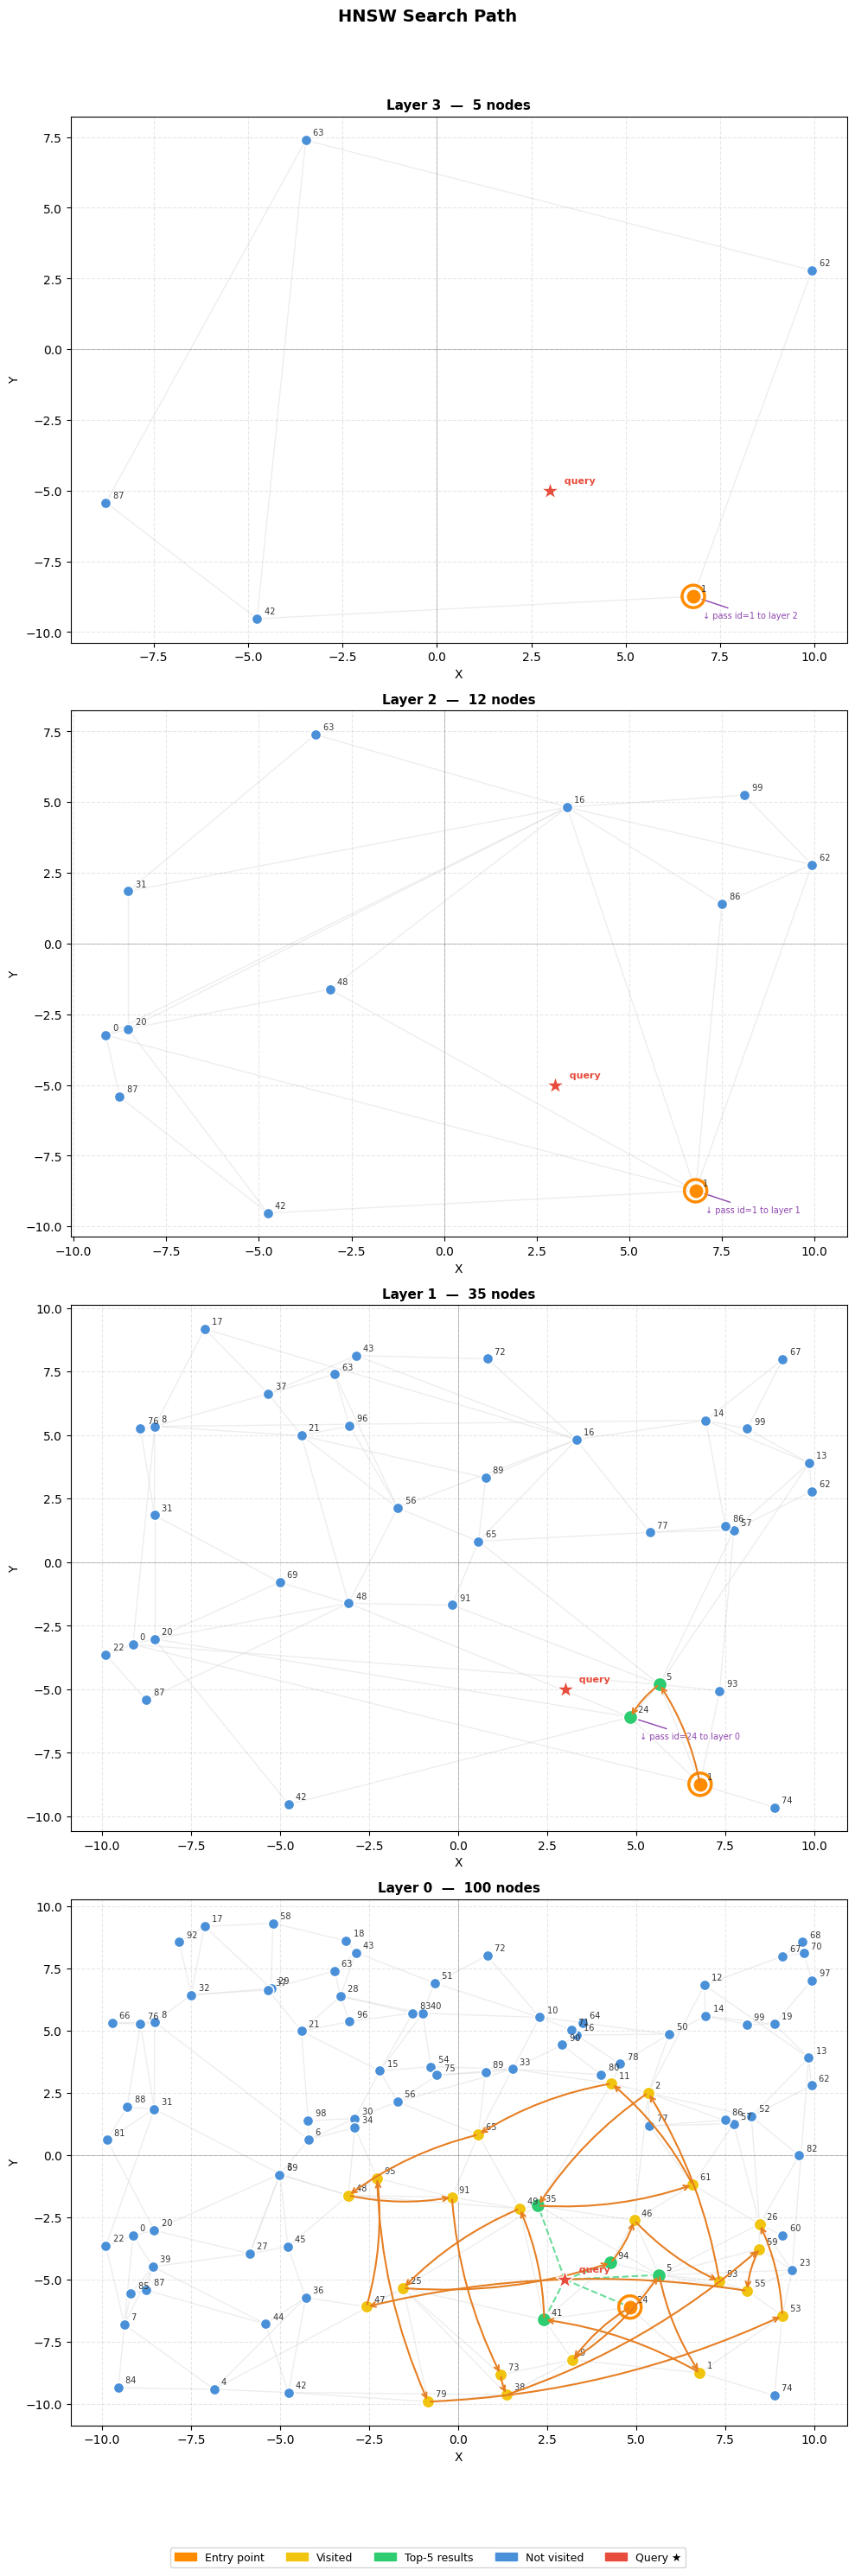

In [4]:
query_vec = np.array([3.0, -5.0])
visualize_hnsw(hnsw, query=query_vec, k=5, ef=20)

## HNSW ANN vs Naive KNN

In [5]:
def naive_knn(query: np.ndarray, vectors: list[np.ndarray], k: int, distance_func=euclidean_distance) -> list[tuple[float, int]]:
    """
    Brute force k-nearest neighbors.
    Compares query against every vector in the database.
    Returns list of (distance, index) sorted closest first.
    """
    distances = []
    for idx, vector in enumerate(vectors):
        dist = distance_func(query, vector)
        distances.append((dist, idx))

    distances.sort(key=lambda x: x[0])
    return distances[:k]

In [20]:
DIM = 256
K=10
EF=50
N_VECTORS=100_000


vectors = np.random.uniform(-1, 1, (N_VECTORS, DIM)).round(6)

query_vec = vectors[0] + 0.15

In [18]:
#build hnsw
bench_hnsw = HNSW(
    M=5,
    ef_construction=20,
    distance_func=cosine_distance
)

for v in vectors:
    bench_hnsw.insert(v)

### Time Complexity

**Insert:** `O(log n)`
Each insertion descends through layers. The number of layers grows as `log n` due to the exponential decay probability. At each layer you do a bounded beam search — bounded because M limits connections, so each search visits at most a fixed number of neighbors.

**Search:** `O(log n)`
Same reason — you descend through `log n` layers with ef=1 (constant work per layer), then do one beam search at layer 0 which is also bounded by ef and M.

This is what makes HNSW special. Brute force is O(n). Most tree-based indexes degrade in high dimensions. HNSW maintains O(log n) even at high dimensions.

---

### Space Complexity

**`O(n · M)`**

Each node stores M connections per layer. Since most nodes only exist at layer 0, and the number of nodes at each higher layer decreases exponentially, the total number of edges across all layers is:

```
layer 0:  n nodes × M edges
layer 1:  n/M nodes × M edges  =  n edges
layer 2:  n/M² nodes × M edges =  n/M edges
...
total ≈ n·M + n + n/M + ... ≈ O(n·M)
```

So M directly controls your memory footprint. Doubling M doubles memory.

---

### In Practice

| Operation | Complexity | Bottleneck |
|---|---|---|
| Build | O(n log n) | n insertions × O(log n) each |
| Search | O(log n) | layer descent + layer 0 beam |
| Memory | O(n · M) | edge storage |

The constant factors matter a lot in practice. The real bottleneck is **distance computation** — each distance call touches the full vector. This is why production systems use SIMD instructions and quantization to speed up distance computation rather than changing the graph structure.

In [22]:
import time

start = time.time()
hnsw_results = bench_hnsw.search(query_vec, k=K, ef=EF)
hnsw_time = time.time() - start
print("HNSW Search time: ", hnsw_time)

HNSW Search time:  0.0027740001678466797


In [24]:
start = time.time()
hnsw_results = naive_knn(query=query_vec, vectors=vectors, k=K, distance_func=cosine_distance)
naive_time = time.time() - start
print("NAIVE Search time: ", naive_time)

NAIVE Search time:  0.3269634246826172


In [26]:
print("HNSW is faster X",int(naive_time / hnsw_time))

HNSW is faster X 117
